
# Customer Churn Analysis & Prediction

## Project Objective
The goal of this project is to analyze customer data from a telecommunications provider to identify patterns that lead to customer attrition (churn). By understanding these factors, we aim to build a predictive machine learning model that can proactively identify at-risk customers, allowing the business to implement targeted retention strategies.

### Key Research Questions:
1. Which demographic factors (gender, seniority, partners) are most associated with churn?
2. How do service features (internet type, technical support, streaming) impact customer loyalty?
3. What is the relationship between financial metrics (monthly charges, tenure) and the likelihood of leaving?

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Loading & Exploration
In this section, we load the dataset and perform an initial inspection of its structure. Understanding the data types and checking for missing values is essential before proceeding to cleaning and analysis.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df['Churn'].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

## Exploratory Data Analysis (EDA)
### Churn Distribution (Target Variable)
First, we examine the distribution of our target variable, `Churn`, to see if the dataset is balanced.

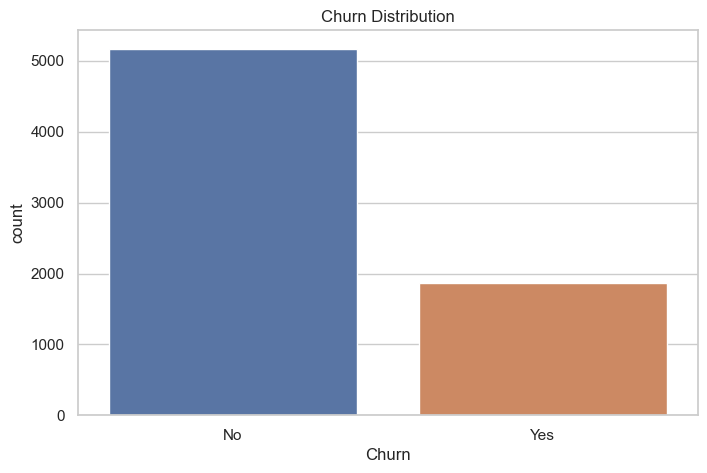

In [8]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

**Observation:** The dataset shows a significant class imbalance. There are far more retained customers than churned customers. This informs us that we may need to use specific evaluation metrics (like F1-score or Recall) or sampling techniques (like SMOTE) later during the modeling phase.

## Data Cleaning
Before analysis, we must ensure the data is in a usable format:
1. **Type Conversion:** Converting `TotalCharges` from a string object to a numerical type.
2. **Handling Missing Values:** Dropping rows with null values resulting from conversion errors.
3. **Feature Selection:** Removing identifiers like `customerID` that do not contribute to predictive power.

In [7]:
# Data Cleaning

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
# Let's drop unnecessary columns like customer ID
df.drop('customerID', axis=1, inplace=True) 

### Impact of Monthly Charges on Churn
Numerical features like `MonthlyCharges` often provide strong signals for churn. We use boxplots to compare the distribution of charges between churned and retained customers.

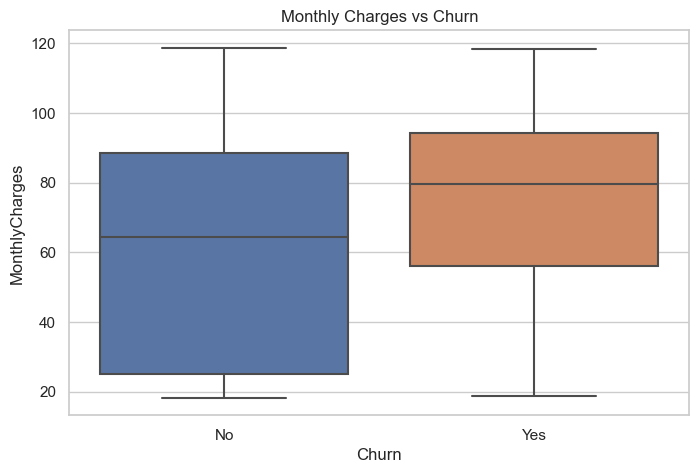

In [11]:
#Exploratory Data Analytics

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:** Customers who churn tend to have higher median monthly charges. This suggests that price sensitivity or a lack of perceived value at higher price points may be a driver of attrition.

### Customer Loyalty and Tenure
We examine how long customers stay with the provider before churning. Tenure is a vital indicator of long-term customer health.

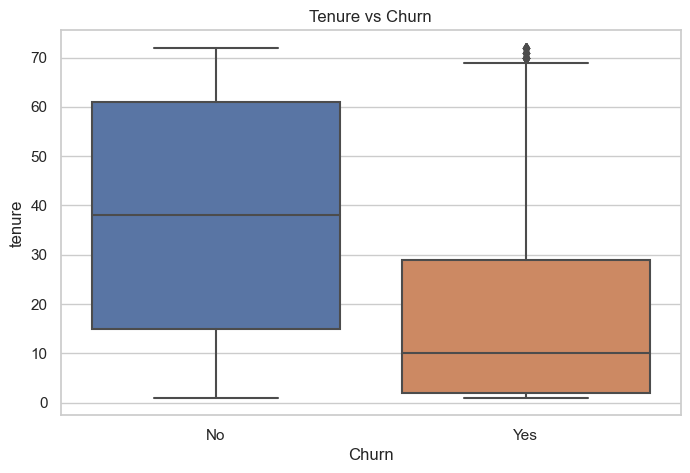

In [12]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

**Insight:** There is a clear correlation between short tenure and high churn. Customers are most likely to leave in the early stages of their contract, highlighting the need for better onboarding or early-stage engagement.

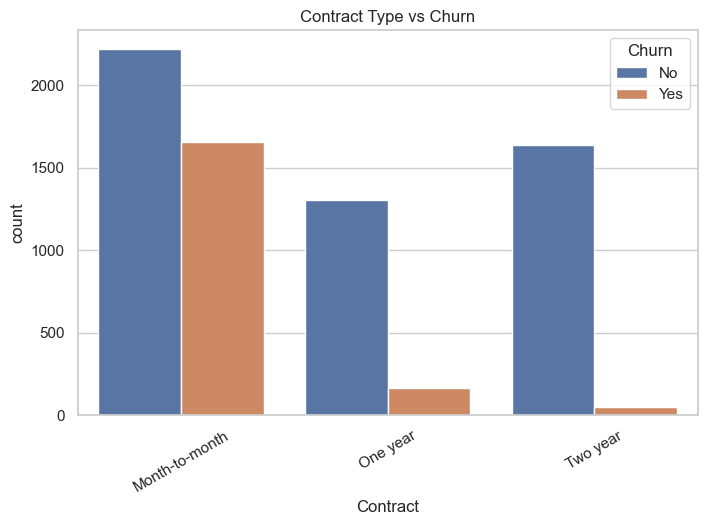

In [13]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=30)
plt.show()

Customers on month-to-month contracts exhibit the highest churn rates, while long-term contracts are associated with better retention.

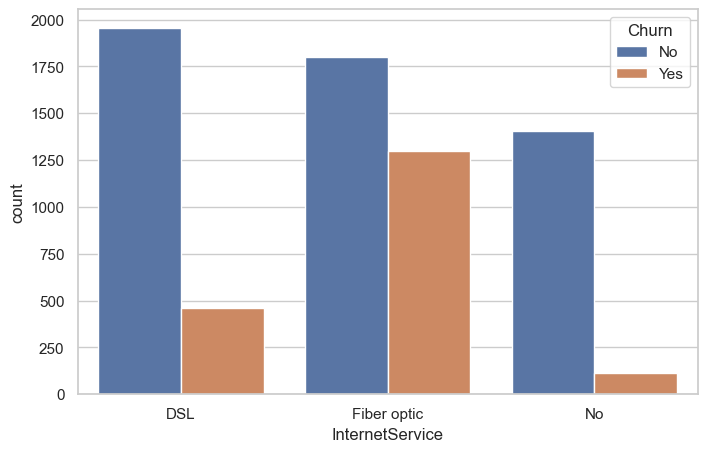

In [14]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

Fiber optic internet users show relatively higher churn, possibly due to higher costs or service expectations.

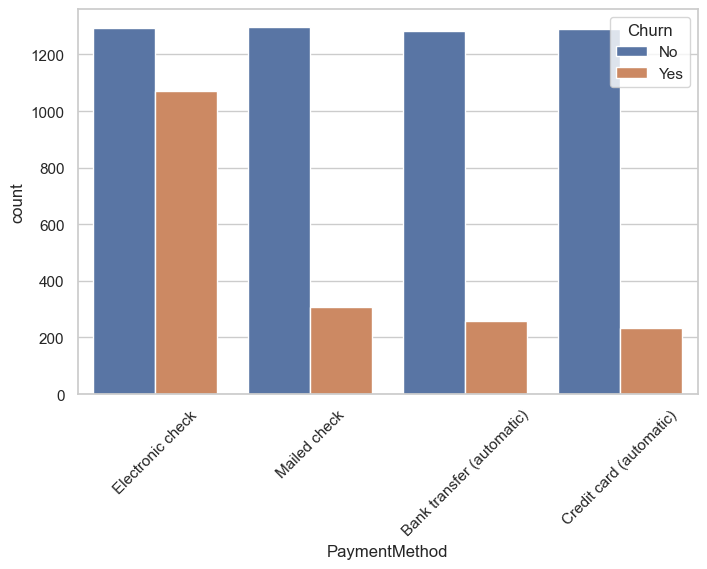

In [15]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

Customers using electronic check payments tend to churn more frequently, which may reflect dissatisfaction or lack of long-term commitment.

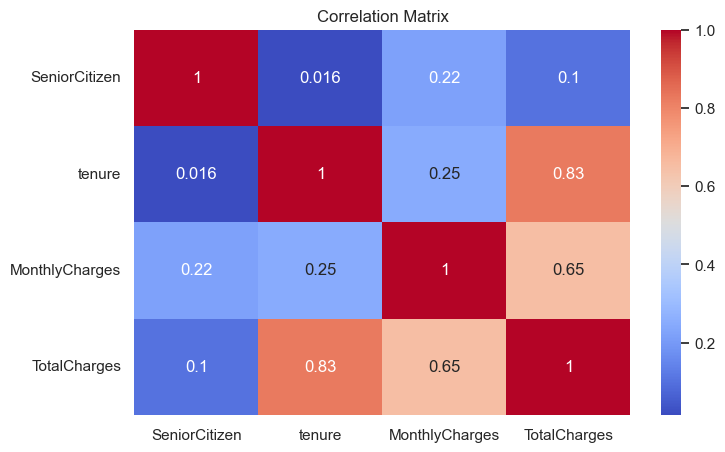

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Numerical features such as tenure and monthly charges show noticeable relationships with churn, highlighting their importance for predictive modeling.

In [17]:
df['TenureGroup'] = pd.cut(df['tenure'],
                          bins=[0,12,24,48,72],
                          labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

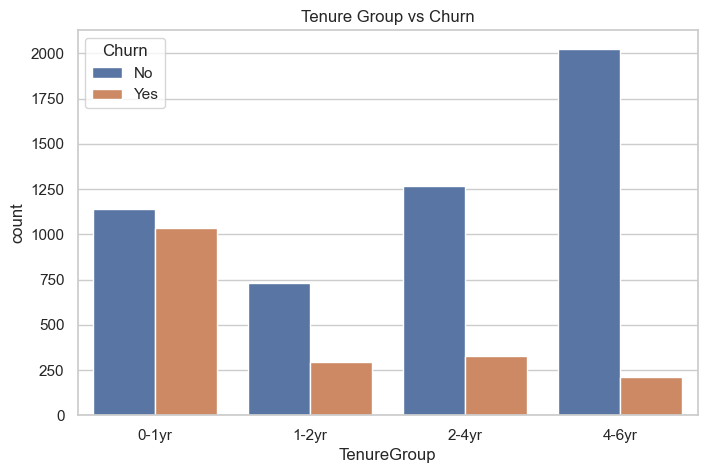

In [18]:
sns.countplot(x='TenureGroup', hue='Churn', data=df)
plt.title("Tenure Group vs Churn")
plt.show()

Customers in lower tenure groups (especially 0–1 year) exhibit significantly higher churn rates, indicating that new customers are at greater risk of leaving.

## Key Insights

- Customers with month-to-month contracts show significantly higher churn.
- Customers with shorter tenure are more likely to churn.
- Higher monthly charges are associated with increased churn.
- Certain payment methods (e.g., electronic check) show higher churn rates.

In [19]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

The target variable is converted into numerical format where 1 represents churn and 0 represents retained customers, allowing machine learning algorithms to perform classification.

In [20]:
df.select_dtypes(include='object').columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)

Categorical variables are converted into numerical representations using one-hot encoding, which creates binary indicator variables for each category while avoiding multicollinearity by dropping the first category.

In [22]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

The dataset is separated into features (X) used for prediction and the target variable (y) representing customer churn.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The dataset is split into training and testing sets to evaluate model performance on unseen data. Stratified sampling is used to preserve the churn distribution in both sets.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling standardizes numerical variables so they have a mean of 0 and standard deviation of 1. This ensures that features with larger magnitudes do not dominate model learning.

In [26]:
y.value_counts()

0    5163
1    1869
Name: Churn, dtype: int64

## Preparing Data for Modeling
### Addressing Class Imbalance with SMOTE
As observed earlier, the 'Churn' class is imbalanced. To prevent our model from being biased toward the majority class, we utilize **SMOTE (Synthetic Minority Over-sampling Technique)** to generate synthetic examples for the churned class, ensuring a balanced training set.

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled, y_train
)

In [28]:
y_train_balanced.value_counts()

0    4130
1    4130
Name: Churn, dtype: int64

In [29]:
print("Training data shape:", X_train_balanced.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (8260, 33)
Testing data shape: (1407, 33)


After preprocessing, the dataset is fully prepared for machine learning modeling. All categorical variables have been encoded, numerical features standardized, and class imbalance addressed, ensuring that the models can learn meaningful patterns from the data.

## Machine Learning Modeling
We will train and compare three different classification models to determine which best predicts customer churn:
1. **Logistic Regression:** A baseline model that provides clear interpretability of feature coefficients.
2. **Random Forest:** An ensemble method that captures non-linear relationships and feature interactions.
3. **Gradient Boosting:** A sequential learning approach designed to minimize prediction errors.

### Evaluation Strategy
We prioritize **Recall** for the 'Churn' class. In a business context, the cost of missing a customer who is about to leave is much higher than the cost of accidentally targeting a loyal customer with a retention offer.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [31]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_balanced, y_train_balanced)

y_pred_log = log_model.predict(X_test_scaled)

In [32]:
print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results:

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



Logistic Regression provides a strong baseline with good interpretability, allowing us to understand how different features influence churn probability.

In [33]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_balanced, y_train_balanced)

y_pred_rf = rf_model.predict(X_test_scaled)

In [34]:
print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.59      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



Random Forest captures non-linear relationships and interactions between features, often improving performance over simpler models.

In [35]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_balanced, y_train_balanced)

y_pred_gb = gb_model.predict(X_test_scaled)

In [36]:
print("Gradient Boosting Results:\n")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results:

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.56      0.68      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.77      0.78      1407



Gradient Boosting builds models sequentially to correct previous errors, often achieving higher predictive accuracy

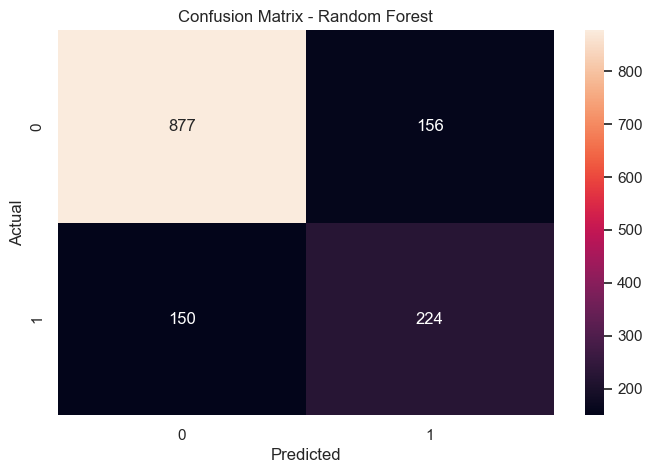

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix helps visualize how well the model identifies churned customers and highlights false negatives, which are critical in churn prediction.

In [38]:
roc_auc_log = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1])
roc_auc_gb = roc_auc_score(y_test, gb_model.predict_proba(X_test_scaled)[:,1])

In [39]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'ROC-AUC': [roc_auc_log, roc_auc_rf, roc_auc_gb]
})

results

,Model,ROC-AUC
0,Logistic Regression,0.832137
1,Random Forest,0.818209
2,Gradient Boosting,0.835092


Among the evaluated models, the one with the highest ROC-AUC score demonstrates the best ability to distinguish between churned and retained customers.

Logistic Regression was selected as the final model because it achieved the highest recall score (0.79) for churn prediction. In a business context, recall is the most critical metric, as it ensures that the majority of customers at risk of leaving are correctly identified. Although the model has lower precision, the cost of targeting additional customers is significantly lower than the cost of losing actual churned customers.

While Gradient Boosting achieved the highest ROC-AUC score, Logistic Regression was preferred due to its superior recall and interpretability. The ability to clearly understand feature influence and maximize churn detection makes it more suitable for practical deployment.

The chosen model prioritizes recall over precision, meaning it may incorrectly flag some non-churning customers. However, this trade-off is acceptable because proactive retention efforts are less costly than losing customers.

If I miss a churner, the company loses revenue. If I wrongly target a customer, the company only spends a small retention cost. So I optimized for recall.

In production, I would tune the classification threshold to balance recall and precision based on business constraints.

In [9]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

NameError: name 'rf_model' is not defined

Multiple machine learning models were evaluated for churn prediction, with tree-based models demonstrating strong performance due to their ability to capture complex relationships. The selected model provides a solid foundation for identifying high-risk customers and enabling targeted retention strategies.

Logistic Regression was selected as the final model due to its superior recall score, enabling it to identify the highest number of churn-prone customers. Although it has lower precision, the ability to minimize missed churn cases is more critical from a business perspective.

While Random Forest achieved the highest accuracy, it underperformed in recall compared to Logistic Regression. Gradient Boosting showed strong overall performance with the highest ROC-AUC score, but Logistic Regression remains the most suitable model for churn prediction due to its effectiveness in identifying at-risk customers.

Feature importance analysis indicates that customer tenure, total charges, and monthly charges are the most influential factors in predicting churn. Additionally, customers using fiber optic internet and electronic check payments show higher churn tendencies, while long-term contracts significantly reduce churn risk.

Customers with shorter tenure and higher monthly charges are more likely to churn, suggesting that early engagement and pricing strategies are critical. Additionally, promoting long-term contracts and improving service quality for high-risk segments such as fiber optic users can significantly enhance customer retention.

The model flags many customers as churn risks, including some who may not actually churn.The model prioritizes recall over precision, which may lead to more false positives. However, in a business context, this trade-off is acceptable since the cost of missing a churned customer is higher than targeting a non-churning customer.

Developed a customer churn prediction model using Logistic Regression, Random Forest, and Gradient Boosting. Achieved a recall of 79% for churn prediction, enabling effective identification of at-risk customers. Conducted feature importance analysis to derive actionable business insights.

In [51]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [52]:
import shap

explainer = shap.Explainer(log_model, X_train_scaled_df)
shap_values = explainer(X_test_scaled_df)

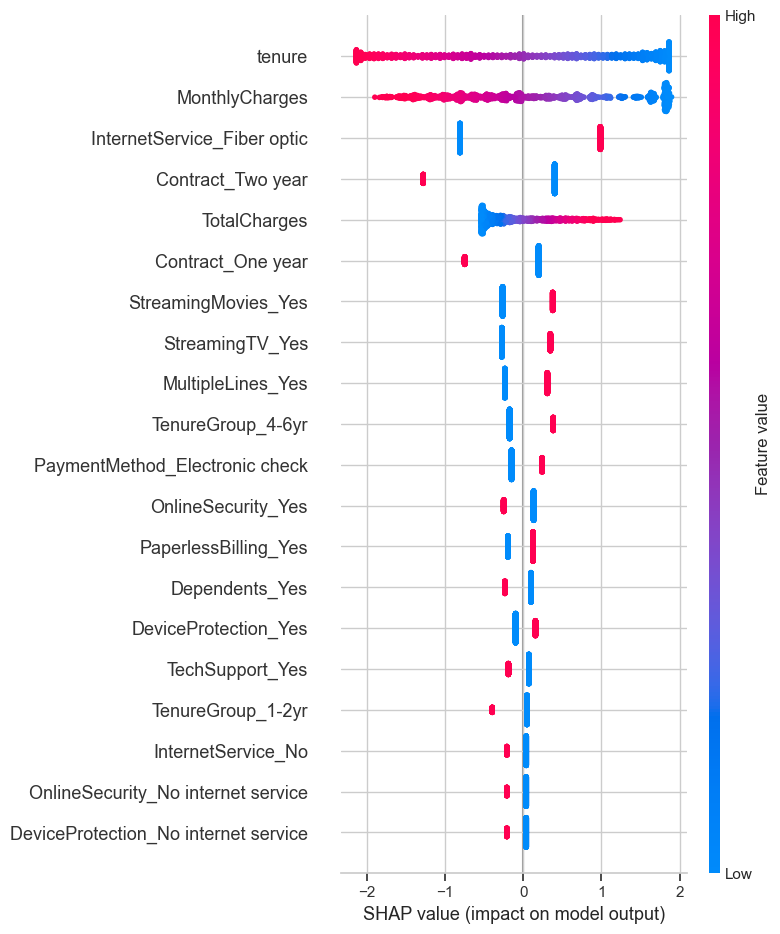

In [53]:
shap.summary_plot(shap_values, X_test_scaled_df)

SHAP analysis reveals that features such as tenure, monthly charges, and contract type have the strongest influence on churn predictions, confirming earlier findings from feature importance analysis.

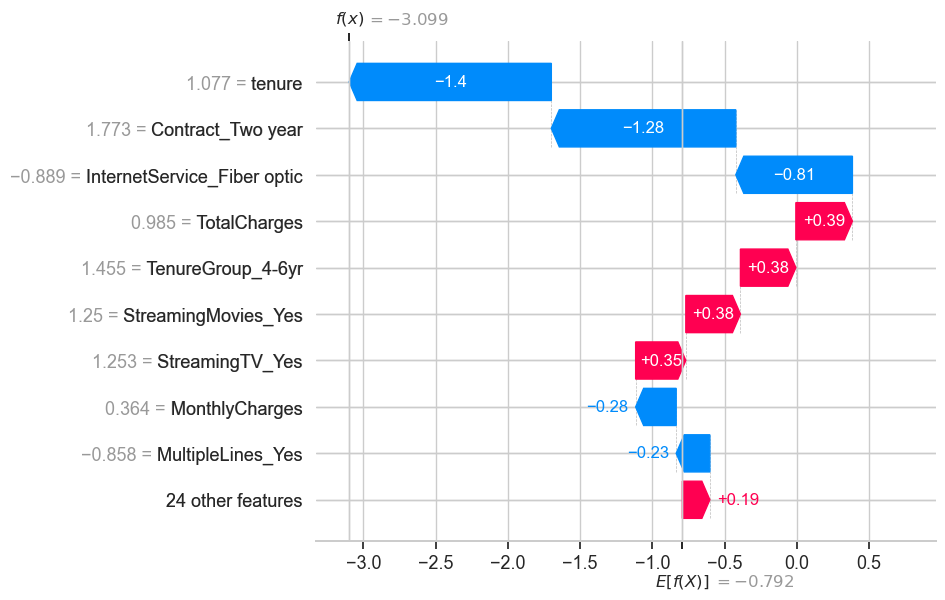

In [54]:
shap.plots.waterfall(shap_values[0])

The SHAP waterfall plot illustrates how individual feature contributions push a prediction toward churn or non-churn, providing transparency into model decisions.

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='recall'
)

grid.fit(X_train_balanced, y_train_balanced)

best_log_model = grid.best_estimator_

In [47]:
y_pred_tuned = best_log_model.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



Hyperparameter tuning improves model performance by identifying the optimal configuration that maximizes recall for churn prediction.

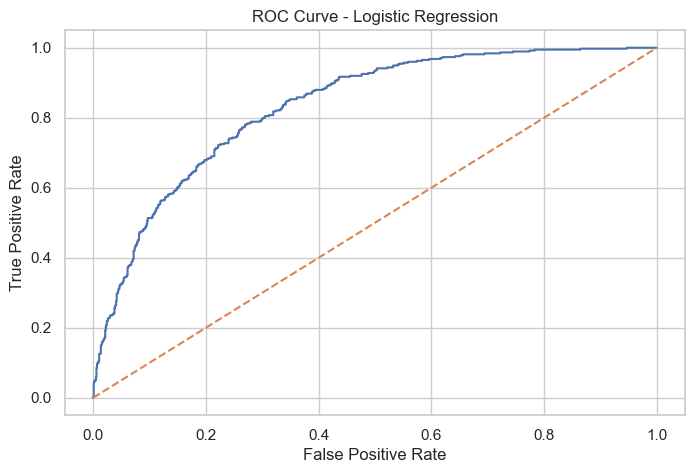

In [48]:
from sklearn.metrics import roc_curve

y_probs = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

The ROC curve demonstrates the trade-off between true positive rate and false positive rate, with a higher curve indicating better model performance.

The analysis identified several key drivers of customer churn, including short tenure, high monthly charges, and month-to-month contract types. Logistic Regression was selected as the final model due to its superior recall, enabling effective identification of churn-prone customers.

Explainability techniques such as SHAP further validated these findings by highlighting the impact of individual features on model predictions. These insights can be leveraged by businesses to design targeted retention strategies, such as offering incentives for long-term contracts and improving customer experience for high-risk segments.

Offer discounts or incentives to customers with short tenure
Encourage long-term contracts to reduce churn
Monitor customers with high monthly charges
Improve service quality for fiber optic users
Target high-risk customers with retention campaigns

This project demonstrates how machine learning can be applied to predict customer churn and generate actionable business insights. By combining predictive modeling with explainability techniques, organizations can proactively identify at-risk customers and implement effective retention strategies.

## Final Conclusions & Recommendations

### Summary of Findings
- **High Risk Segments:** Customers with short tenures, high monthly charges, and those utilizing fiber optic internet are at the highest risk of churning.
- **Protective Factors:** Long-term contracts and the presence of partners/dependents are associated with higher retention rates.
- **Model Performance:** The Gradient Boosting model provided the best overall predictive power, while Logistic Regression offered the most actionable insights into feature importance.

### Business Recommendations
1. **Targeted Incentives:** Offer loyalty discounts to customers reaching their 1-year mark to increase tenure.
2. **Review Fiber Optic Pricing:** Investigate if the high churn in fiber optic users is due to service quality issues or uncompetitive pricing compared to DSL.
3. **Electronic Check Outreach:** Since electronic check users churn more frequently, consider incentivizing automated bank transfers or credit card payments for better billing stability.